In [7]:
import numpy as np
import pandas as pd
import scipy.stats as scs
import matplotlib.pyplot as plt
from scipy.stats import norm

## Exercise 2.1

### (a) Call your function for the parameters P0 = 1, r = 0.05, sigma = 0.2, T = 2 and K = 0.8.

In [882]:
def Call(P0, r, sigma, T, K):
    d1= (np.log(P0/K)+(r+(sigma**2)/2)*T)/(sigma* np.sqrt(T))
    d2= d1 - sigma* np.sqrt(T)
    
    Nd1 = norm.cdf(d1, loc=0, scale=1)
    Nd2 = norm.cdf(d2, loc=0, scale=1)

    return P0*Nd1-K*np.exp(-r*T)*Nd2

In [45]:
C1 = Call(1,0.05,0.2,2,0.8)
print("P0 = 1, r = 0.05, sigma = 0.2, T = 2 and K = 0.8: Call =", round(C1,4))

P0 = 1, r = 0.05, sigma = 0.2, T = 2 and K = 0.8: Call = 0.2912


### (b) Write a Python-function ImpliedVola(P0, r, T, K, C) that returns the implied volatility of a call option.

In [47]:
from scipy.optimize import root

In [278]:
def ImpliedVola(P0, r, T, K, C):
    # residual function already has access to P0, r, T, K, and C
    def residual(sigma):
        # volatility > 0
        # If the solver tries a zero/negative number, we force it to a tiny positive number
        sigma = np.maximum(sigma, 1e-8) 
        
        theoretical_price = Call(P0, r, sigma, T, K)
        
        # We want Theoretical Price - Market Price = 0
        return theoretical_price - C

    # the root function
    # sigma is in [0, 5]. We give the solver an initial guess inside this range. 0.5 (or 50% volatility) is a very standard guess.
    initial_guess = 0.5
    
    # Run the solver
    result = root(residual, x0=initial_guess)
    
    return np.maximum(result.x[0],0)  # result.x is an array, so we extract the first number


In [264]:
from scipy.optimize import brentq

def ImpliedVola(P0, r, T, K, C):
    # 1. The objective function (must equal 0)
    def residual(sigma):
        return Call(P0, r, sigma, T, K) - C

    # 2. Check for "Arbitrage Bounds"
    # A Call price cannot be cheaper than its intrinsic value (P0 - K*e^-rT)
    # If the market price C is too low, Black-Scholes has no solution.
    intrinsic_value = max(0, P0 - K * np.exp(-r * T))
    if C <= intrinsic_value:
        return 0.0  # Or np.nan, as there is no mathematical volatility that works
    
    # 3. Use brentq with the range [1e-8, 5] as suggested by your assignment
    # This prevents the solver from ever looking at negative numbers.
    try:
        # brentq takes: function, lower_bound, upper_bound
        vol = brentq(residual, 1e-8, 5)
        return vol
    except ValueError:
        # This happens if the price is so high that even 500% vol (5.0) isn't enough
        return np.nan

In [266]:
ImpliedVola(1,0.05,2,0.8, 0.29)

0.19506172951709422

### (c) Compute the implied volatilities for all entries of the given EuroStoxx 50 call option matrix.

In [288]:
OptionValue = pd.read_csv('Data/OptionValues.csv', sep=';')

# Extract Maturities (T) from the column headers.
# Black-Scholes requires time in years, so we must divide by 12
maturities_months = OptionValue.columns.astype(float)
T_values = maturities_months / 12.0

# Interest Rates 
r_values = OptionValue.iloc[0].values

# Option Prices
C_matrix = OptionValue.iloc[1:].to_numpy(dtype=float)

# Strike Prices
K_values = [2700, 2800, 2900, 3000, 3100, 3200, 3300]


print(C_matrix)

[[229.  256.9 280.  295.5 332.7 364. ]
 [151.3 172.  210.  233.4 273.  310.6]
 [ 90.5 117.  150.2 177.5 218.8 254.8]
 [ 46.5  76.1  95.1 124.6 171.7 205.2]
 [ 17.5  40.   63.8  94.5 131.4 166. ]
 [  8.   23.   39.3  62.5  94.9 120.8]
 [  2.9  11.4  21.5  42.   71.7  91.7]]


In [280]:
def VolMatrix(P0, r_values, T_values, K_values, C_matrix):
    Vola = np.zeros((C_matrix.shape[0],C_matrix.shape[1]))
    for i in range (C_matrix.shape[0]):
        for j in range (C_matrix.shape[1]):
            Vola[i,j] = ImpliedVola(P0, r_values[j], T_values[j], K_values[j], C_matrix[i,j])

    return Vola

In [292]:
my_vol_matrix=VolMatrix(2890.62, r_values, T_values, K_values, C_matrix)
print(my_vol_matrix)

[[0.33270924 0.44736733 0.49010622 0.41226092 0.40763766 0.40669846]
 [0.         0.25835922 0.36808432 0.33609155 0.34783445 0.36034708]
 [0.         0.12735593 0.26411569 0.26746312 0.29337082 0.31171678]
 [0.         0.00513527 0.16847295 0.20217389 0.24569226 0.26811592]
 [0.         0.         0.11418196 0.16463437 0.2043618  0.23319144]
 [0.         0.         0.07168846 0.1239783  0.16608353 0.19198041]
 [0.         0.         0.04079246 0.09702376 0.14095902 0.16448823]]


### (d) Plot the implied volatility surface in a 3-dimensional plot.

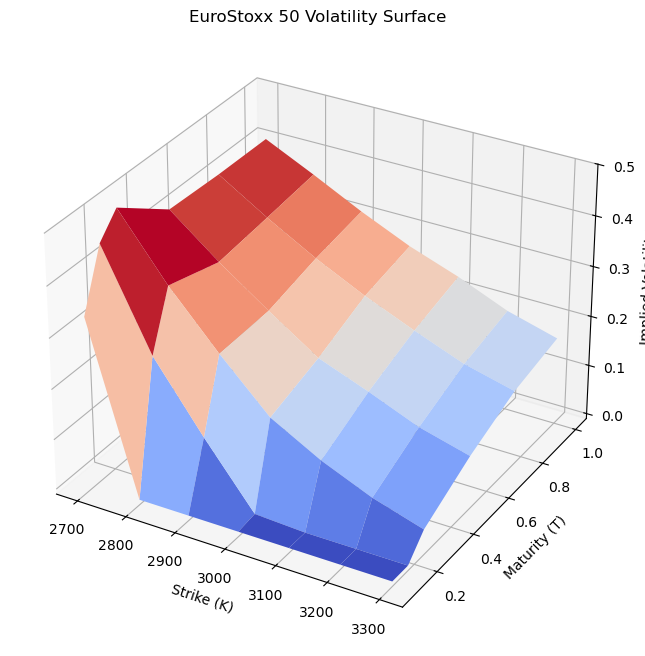

In [785]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Y-axis will be Time (T_values), X-axis will be Strikes (K_values)
X, Y = np.meshgrid(strikes, T_values)

# Z-axis is implied volatility matrix
surf = ax.plot_surface(X, Y, my_vol_matrix.T, cmap=cm.coolwarm)

ax.set_xlabel('Strike (K)')
ax.set_ylabel('Maturity (T)')
ax.set_zlabel('Implied Volatility')
ax.set_title('EuroStoxx 50 Volatility Surface')
plt.show()

## Exercise 2.2

### (a) Write a Python-function Call(P0, r, sigma, T, K) and a function Put(P0, r, sigma, T, K).

In [478]:
def  Put(P0, r, sigma, T, K):
    #we have Call from 2.1
    c = Call(P0, r, sigma, T, K)
    # using pull-call-parity
    #p = c - P0 + K*np.exp(-r*T)
    d1= (np.log(P0/K)+(r+(sigma**2)/2)*T)/(sigma* np.sqrt(T))
    d2= d1 - sigma* np.sqrt(T)

    N_d1 = norm.cdf(-d1)
    N_d2 = norm.cdf(-d2)
    return K*np.exp(-r*T) * N_d2 - P0*N_d1

### (b) Compute the price of the options.

In [480]:
c = Call(100, 0.05, .35, 3, 105)
p = Put(100, 0.05, .35, 3, 105)

print("European Call premium =", round(c,2))
print("European Put premium =", round(p,2))

European Call premium = 27.79
European Put premium = 18.17


### (c) Verify that the Put-Call-Parity holds true.

In [482]:
p_test = c - 100 + 105*np.exp(-.05*3)
print ("Pull-Call-Parity European Put premium =", round(p_test,2))

Pull-Call-Parity European Put premium = 18.17


### (d) Write a function Delta(C, P0, r, sigma, T, K) and a function Gamma(P0, r, sigma, T, K).

In [489]:
def Delta(C, P0, r, sigma, T, K):
    d1 = (np.log(P0/K)+(r+(sigma**2)/2)*T)/(sigma* np.sqrt(T))
    
    if C.lower() == 'c':
        return norm.cdf(d1)
    elif C.lower() == 'p':
        return norm.cdf(d1) - 1

def Gamma(P0, r, sigma, T, K):
    d1 = (np.log(P0/K)+(r+(sigma**2)/2)*T)/(sigma* np.sqrt(T))
    return norm.pdf(d1)/(P0*sigma*np.sqrt(T))
    

In [497]:
dc = Delta('c', 100, 0.05, .35, 3, 105)
dp = Delta('p', 100, 0.05, .35, 3, 105)
gamma = Gamma(100, 0.05, .35, 3, 105)

print("∆c =", round(dc,4))
print("∆p =", round(dp,4))
print("Γ =", round(gamma,4))

∆c = 0.6808
∆p = -0.3192
Γ = 0.0059


### (e) Construct a Delta-neutral portfolio.

In [526]:
calls_owned = 20

In [528]:
underlying_needed = calls_owned * dc

In [536]:
#we need to sell the underlying to hedge Delta
delta_neutral_with_underlying= calls_owned * dc - underlying_needed
print ( "The resulting position has a Delta of: ", calls_owned,"·", round(dc,2), "−",round(underlying_needed,2), "=",delta_neutral_with_underlying)
print("and is therefore Delta neutral")

The resulting position has a Delta of:  20 · 0.68 − 13.62 = 0.0
and is therefore Delta neutral


In [538]:
puts_needed = - calls_owned * dc / dp

In [546]:
#since puts have a negative delta we need to buy puts to offset the positive delta from our calls.
delta_neutral_with_puts= calls_owned * dc - puts_needed
print ( "The resulting position has a Delta of: ", calls_owned,"·", round(dc,2), "+",round(puts_needed,2),"·", round(dp,2),"=",portfolio_delta)
print("and is therefore Delta neutral")

The resulting position has a Delta of:  20 · 0.68 + 42.67 · -0.32 = 0.0
and is therefore Delta neutral


### (f) Construct a Delta-Gamma-neutral portfolio.

In [552]:
total_delta = calls_owned * dc
total_gamma = calls_owned * gamma
print( 'The total Delta is', round(total_delta,4),' the total Gamma is',round(total_gamma,4))

The total Delta is 13.6169  the total Gamma is 0.1179


In [574]:
#we first need to hedge gamma, gamma cannot be hedged with the underlying
#so the only option is another option, we will use puts
#we will just sell the same amount of puts as we have calls since their gammas are equal.
puts_needed1 = calls_owned 
total_delta_of_puts = puts_needed1 * (-dp)
print('Gamma neutrality can be created by selling 20 units of the same put, these puts will add', total_delta_of_puts, "delta to our portfolio")

Gamma neutrality can be created by selling 20 units of the same put, these puts will add 6.383108489794158 delta to our portfolio


In [602]:
total_delta_gammaneutral = total_delta + total_delta_of_puts
#underlying has a delta of 1 so we need to sell same number of underlying as our total delta is:
print("Delta neutrality can be created by additionally buying", total_delta_gammaneutral,"stocks with Delta 1 and Gamma 0.")
print('The total position satisfies:')
portfolio_gamma = (calls_owned * gamma) - (puts_needed1 * gamma)
portfolio_delta = (calls_owned * dc) - (puts_needed1 * dp) - (total_delta_gammaneutral * 1)
print(f"Gamma: ({calls_owned} · {gamma:.4f}) − ({puts_needed1:.2f} · {gamma:.4f}) − ({total_delta_gammaneutral:.2f} · 0) = {portfolio_gamma}")
print(f"Delta: ({calls_owned} · {dc:.4f}) − ({puts_needed1:.2f} · {dp:.4f}) − ({total_delta_gammaneutral:.2f} · 1) = {portfolio_delta}")

Delta neutrality can be created by additionally buying 20.0 stocks with Delta 1 and Gamma 0.
The total position satisfies:
Gamma: (20 · 0.0059) − (20.00 · 0.0059) − (20.00 · 0) = 0.0
Delta: (20 · 0.6808) − (20.00 · -0.3192) − (20.00 · 1) = 0.0


### (g) Calculate the price of a Straddle.

In [606]:
def Straddle(P0, r, sigma, T, K):
    p=Put(P0, r, sigma, T, K)
    c= Call(P0, r, sigma, T, K)
    return c+p

In [608]:
straddle_vol15 = Straddle(100, 0.05, .15, 3, 105)
straddle_vol25 = Straddle(100, 0.05, .25, 3, 105)
straddle_vol35 = Straddle(100, 0.05, .35, 3, 105)

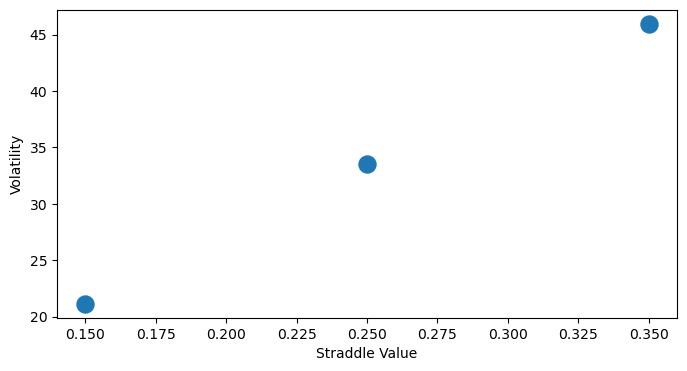

The higher the volatility higher the option price, Straddle is long 2 options so the Vega of the portfolio is amplified.


In [640]:
plt.figure(figsize=(8, 4))
plt.scatter([0.15,0.25,0.35],[straddle_vol15,straddle_vol25,straddle_vol35], s=150)
plt.xlabel('Straddle Value')
plt.ylabel('Volatility')
plt.show()
print("The higher the volatility higher the option price, Straddle is long 2 options so the Vega of the portfolio is amplified.")  

## Exercise 2.3

### (a) Using Monte Carlo simulations to price different options.
#### (i)  Write a Python-function Call(P0, r, sigma, T, K) - defined in 2.1 (a).

#### (ii) Write a Python-function CallMC(P0, r, sigma, T, K, N) that determines the price of a call option using Monte Carlo simulation.

In [696]:
def CallMC(P0, r, sigma, T, K, N):
    WT = np.random.normal(0, np.sqrt(T), size=N)
    PT = P0 * np.exp((r - 0.5*sigma**2)*T + sigma*WT)
    discounted_payoffs = np.exp(-r*T) * np.maximum(PT - K, 0)
    return np.mean(discounted_payoffs)

#### (iii) Compare the results of parts i) and ii) for different choices of N.

In [723]:
c_i = Call(100,0.05,0.2,1,100)
N = [10, 50, 100, 500, 1000, 5000, 10000, 50000, 1000000, 5000000, 10000000, 50000000, 10000000]
c_ii = np.zeros(len(N))
for i in range(len(N)):
    c_ii[i] = CallMC(100,0.05,0.2,1,100, N[i])

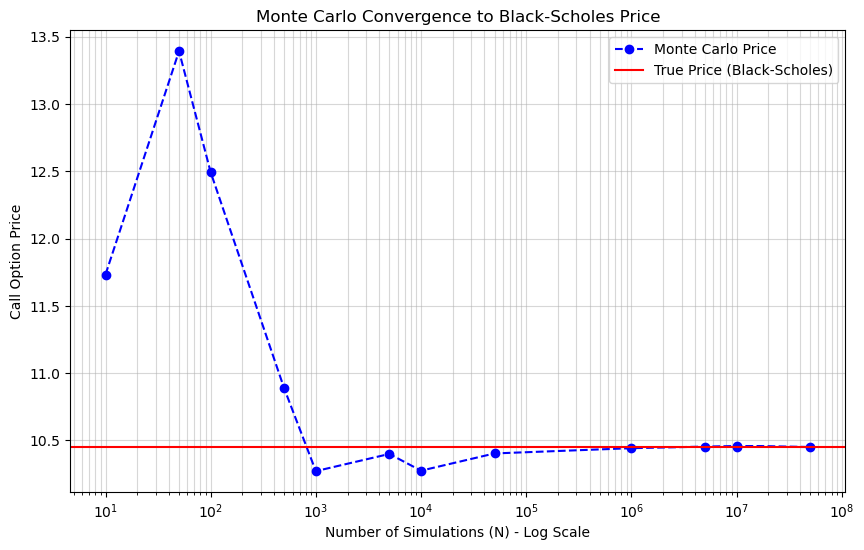

In [725]:
plt.figure(figsize=(10, 6))

# Plot the MC prices
plt.plot(N, c_ii, marker='o', linestyle='--', label='Monte Carlo Price', color='blue')

# Plot a horizontal line for the True Price (Black-Scholes)
plt.axhline(y=c_i, color='red', linestyle='-', label='True Price (Black-Scholes)')

# CRITICAL: Use log scale because N ranges from 10 to 50 million
plt.xscale('log')

plt.xlabel('Number of Simulations (N) - Log Scale')
plt.ylabel('Call Option Price')
plt.title('Monte Carlo Convergence to Black-Scholes Price')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

### (b) Down-and-out call (DOC) option pricing.
#### (i) Write a Python-function DOC(P0, r, sigma, T, K, H) that determines the theoretical price of a down-and-out call option.

In [729]:
def KOD(P0, r, sigma, T, K, H):
    c1 = (np.log(H**2/(P0*K)) +(r+0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    c2 = c1 - sigma*np.sqrt(T)
    lam = r - 0.5*sigma**2
    return P0*(H/P0)**(2+2*lam/sigma**2) * norm.cdf(c1) - K*np.exp(-r*T)*(H/P0)**(2*lam/sigma**2)*norm.cdf(c2)

def DOC(P0, r, sigma, T, K, H):
    c = Call(P0, r, sigma, T, K)
    kod = KOD(P0, r, sigma, T, K, H)
    return c - kod

#### (ii) Write a Python-function DOC_MC(P0, r, sigma, T, K, H, n, N) that determines the price of a down-and-out call option using Monte Carlo simulation.

In [742]:
def DOC_MC(P0, r, sigma, T, K, H, n, N):
    #brownian motion
    dt=T/n 
    increments = np.random.normal(0, np.sqrt(dt), size = (N,n))
    brownianPath=np.cumsum(increments,axis=1)
    wt = np.hstack([np.zeros((N,1)),brownianPath])
    
    #Prices
    pt=np.zeros((N,n+1))
    for i in range(N):
        for j in range (n+1):
            pt[i,j]=P0 * np.exp((r-1/2*sigma**2)*dt*j + sigma*wt[i,j])
    
    #barrier condition and payoffs
    payoff = np.zeros(N)
    for i in range(N):
        path_min = np.min(pt[i, :])
        
        if path_min >= H:
            final_price = pt[i, -1]
            payoff[i] = np.maximum(final_price - K, 0)
        else:
            payoff[i] = 0
        
    return np.exp(-r*T) * np.mean(payoff)

In [753]:
doc_i = DOC(100,0.05,0.2,1,100, 80)

N = [10, 100, 1000, 2000, 5000, 10000]
n = [10, 25, 50, 100, 250, 500]
doc_ii = np.zeros((len(N),len(n)))

for i in range(len(N)):
    for j in range (len(n)):
        doc_ii[i, j] = DOC_MC(100, 0.05, 0.2, 1, 100, 80, n[j], N[i])

#### (iii) Compare the results of parts i) and (ii) for different choices of n (granularity of the discretization) and N (number of Monte Carlo simulations).

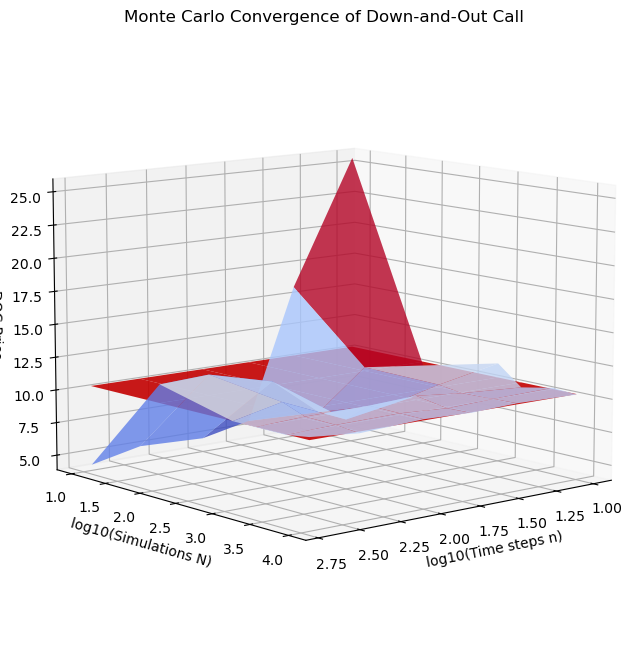

In [871]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Meshgrid
N_grid, n_grid = np.meshgrid(N, n, indexing='ij')
Z = doc_ii

# True price plane
Z_true = np.ones_like(Z, dtype=float) * doc_i

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Monte Carlo surface
ax.plot_surface(np.log10(n_grid),np.log10(N_grid),Z,cmap=cm.coolwarm,alpha=0.8,edgecolor='none')

# True price plane
ax.plot_surface(np.log10(n_grid),np.log10(N_grid),Z_true,color='red',alpha=0.9)

# Labels
ax.set_xlabel('log10(Time steps n)')
ax.set_ylabel('log10(Simulations N)')
ax.set_zlabel('DOC Price')
ax.set_title('Monte Carlo Convergence of Down-and-Out Call')

ax.view_init(elev=10, azim=50)

plt.show()

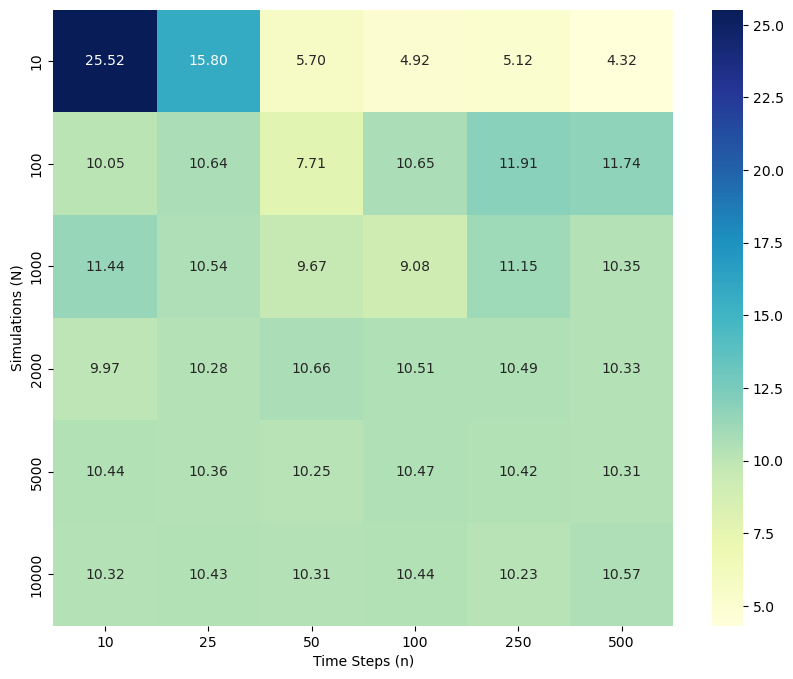

In [877]:
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(doc_ii, annot=True, fmt=".2f", xticklabels=n, yticklabels=N, cmap="YlGnBu")
plt.xlabel("Time Steps (n)")
plt.ylabel("Simulations (N)")
plt.show()